__EN3160 Assignment 1 on Intensity Transformations and Neighborhood
Filtering__

### (1). Intensity transformation

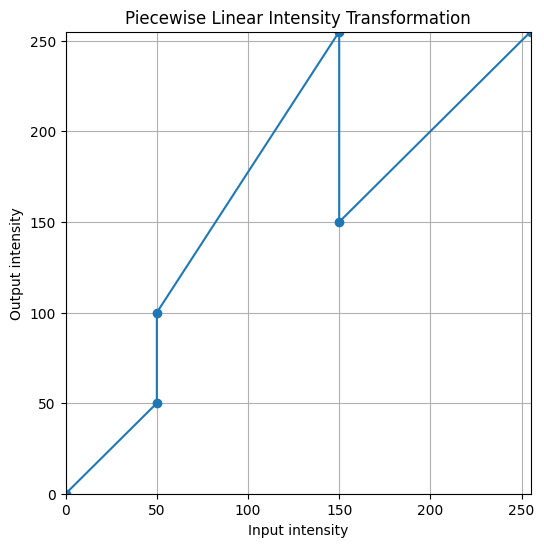

In [85]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

##piecewise linear intensity transformation
breakpoints = np.array([
    [0, 0],
    [50, 50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255, 255]
], dtype=np.float32)

x = breakpoints[:, 0]
y = breakpoints[:, 1]

plt.figure(figsize=(6, 6))

plt.plot(x, y, marker='o')

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Piecewise Linear Intensity Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.grid(True)
plt.show()

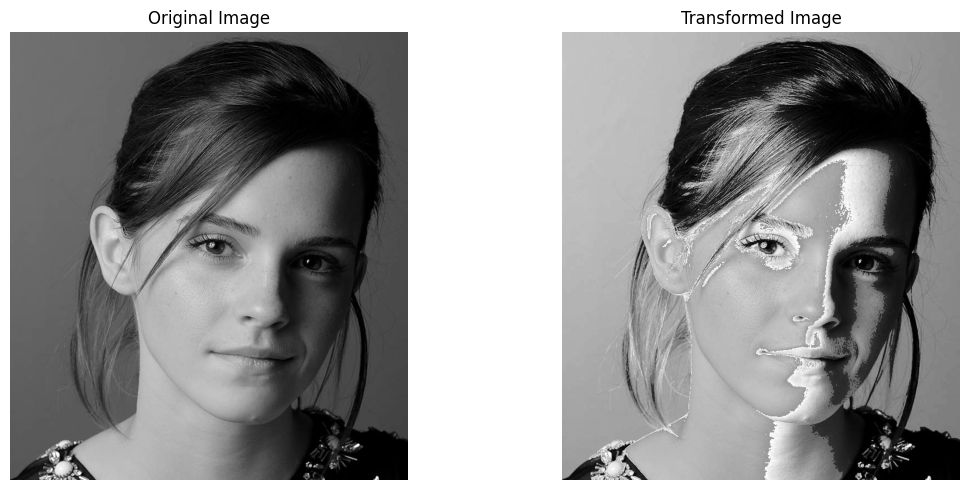

In [86]:
## define the intensity transformation function
def intensity_transformation(im,breakpoints):
    x = breakpoints[:, 0]
    y = breakpoints[:, 1]
    im_transformed = np.interp(im.flatten(), x, y)
    return im_transformed.reshape(im.shape).astype(np.uint8)

## read the image
im = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q1.jpeg",cv2.IMREAD_GRAYSCALE)

## apply the intensity transformation
transformed = intensity_transformation(im, breakpoints)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(im, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(transformed, cmap="gray")
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

### (2).Brain image enhancement

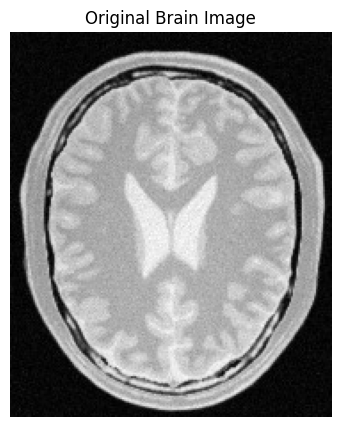

In [87]:
brain = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q2.jpeg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6, 5))
plt.imshow(brain, cmap="gray")
plt.title("Original Brain Image")
plt.axis("off")
plt.show()

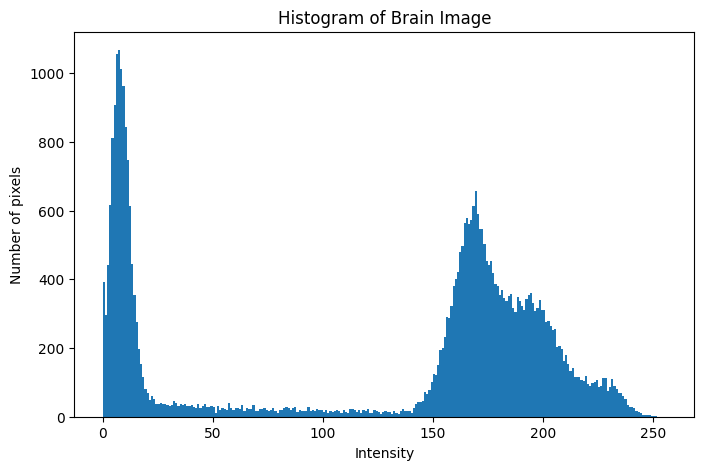

In [88]:
##get the distribution of pixel intensities in the brain image
plt.figure(figsize=(8, 5))

plt.hist(brain.ravel(), bins=256, range=(0, 256))

plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Histogram of Brain Image")

plt.show()

according to the histogram most of the white matter approximatelty in the range of 150 - 220 intensities. So that we should define new breakpoints to enhance the white matters.

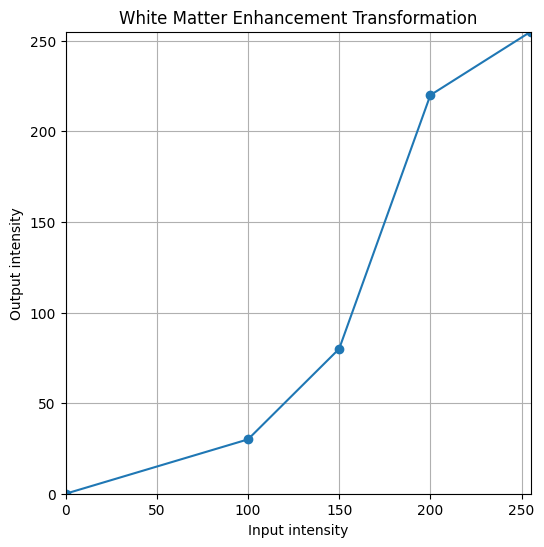

In [89]:
## define the breakpoints for the piecewise linear transformation
white_breakpoints = np.array([
    [0, 0],
    [100, 30],
    [150, 80],
    [200, 220],
    [255, 255]
], dtype=np.float32)
plt.figure(figsize=(6, 6))

plt.plot(
    white_breakpoints[:, 0],
    white_breakpoints[:, 1],
    marker='o'
)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("White Matter Enhancement Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)

plt.show()



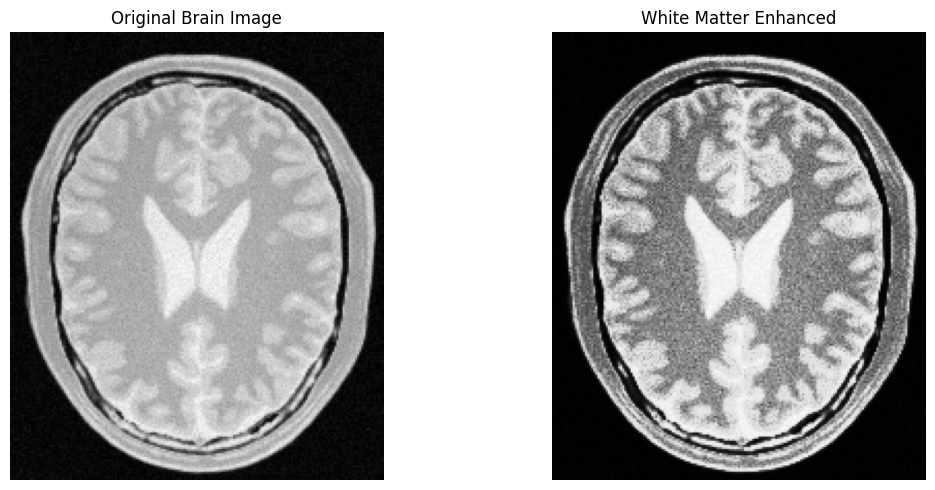

In [90]:
white_enhanced = intensity_transformation(brain,white_breakpoints)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(brain, cmap="gray")
plt.title("Original Brain Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(white_enhanced, cmap="gray")
plt.title("White Matter Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

according to the histogram most of the gray matters in the ranges of approximately 80 - 150 intensities.

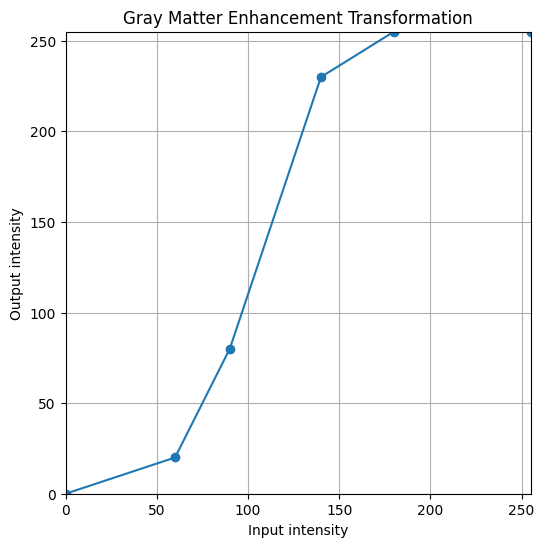

In [91]:
gray_breakpoints = np.array([
    [0, 0],
    [60, 20],
    [90, 80],
    [140, 230],
    [180, 255],
    [255, 255]
], dtype=np.float32)

plt.figure(figsize=(6, 6))

plt.plot(
    gray_breakpoints[:, 0],
    gray_breakpoints[:, 1],
    marker='o'
)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Gray Matter Enhancement Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)

plt.show()

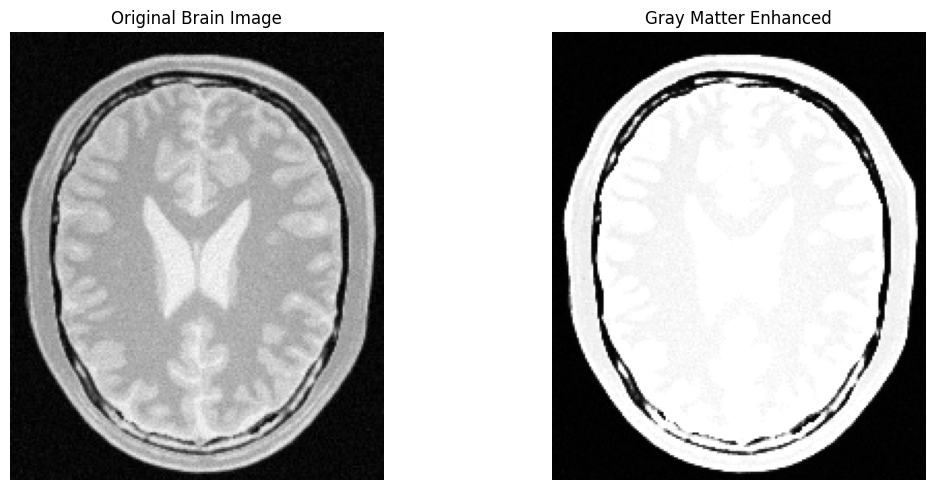

In [92]:
gray_enhanced = intensity_transformation(brain,gray_breakpoints)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(brain, cmap="gray")
plt.title("Original Brain Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_enhanced, cmap="gray")
plt.title("Gray Matter Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

### (3).Gamma correction

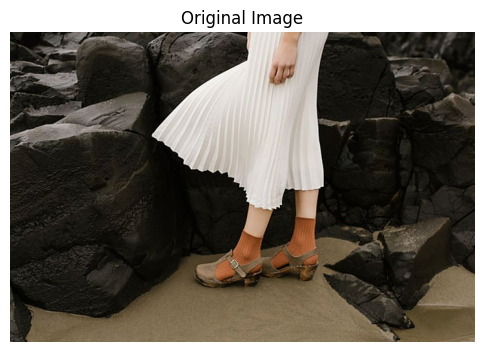

In [93]:
img = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q3.jpeg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 5))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

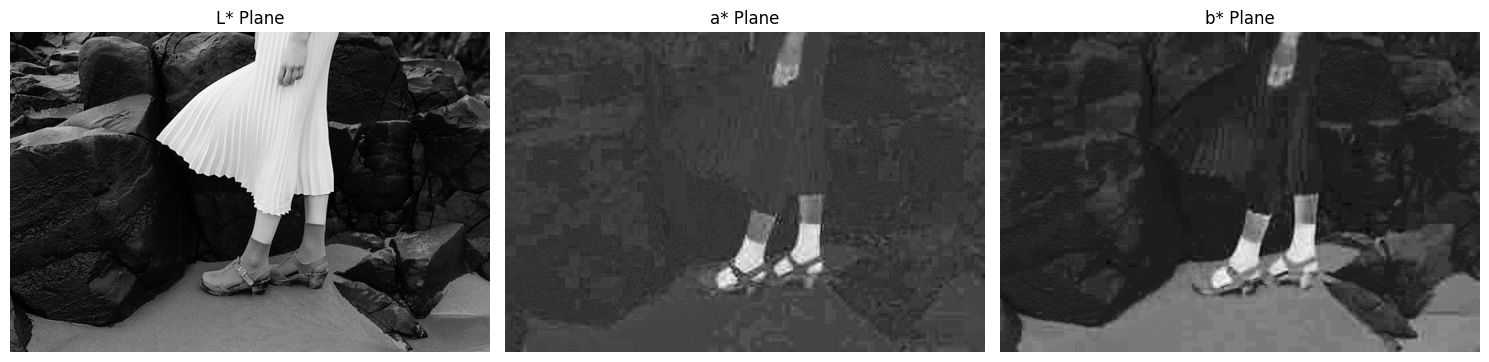

In [94]:
## convert the image to LAB color space and split the channels
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

## visualize the L*, a*, and b* planes
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(L, cmap="gray")
plt.title("L* Plane")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(a, cmap="gray")
plt.title("a* Plane")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(b, cmap="gray")
plt.title("b* Plane")
plt.axis("off")

plt.tight_layout()
plt.show()

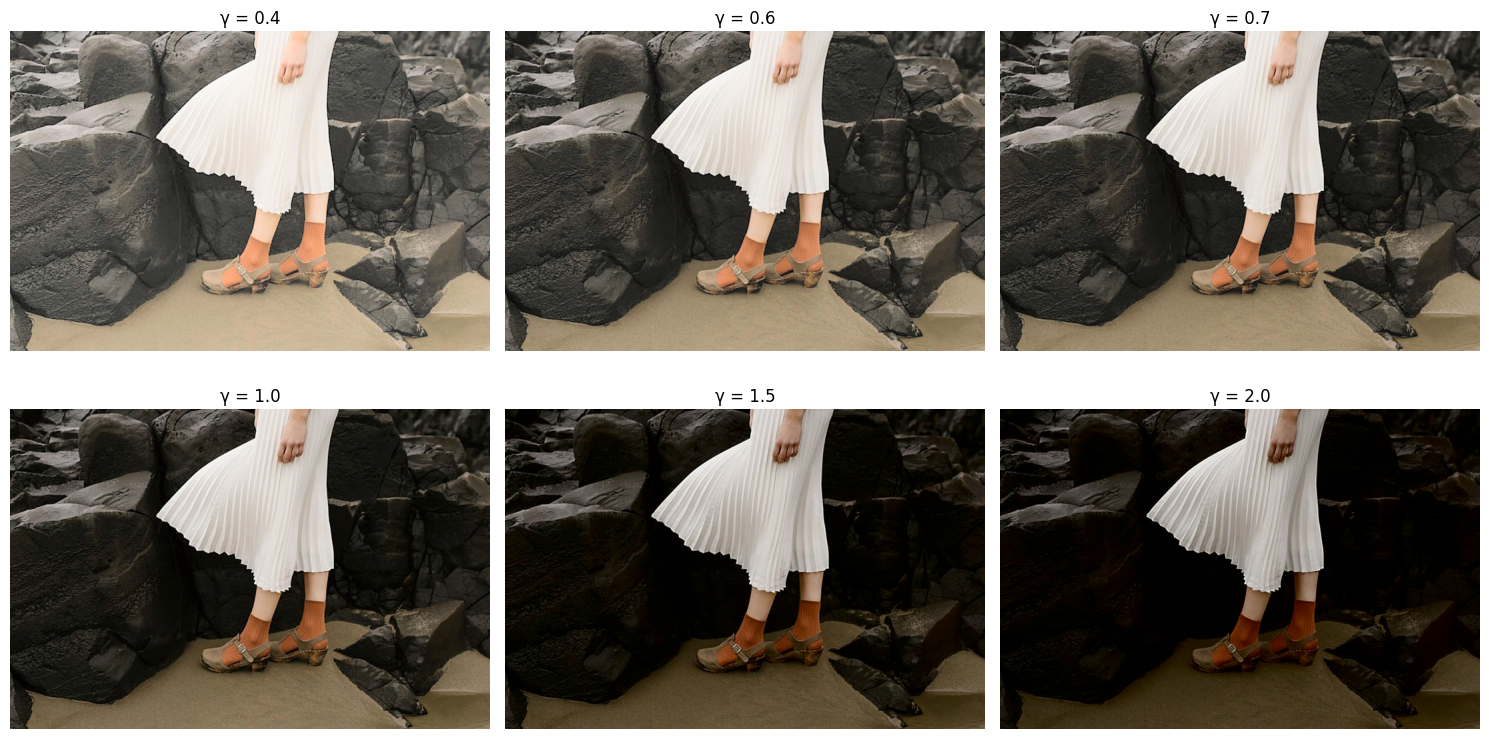

In [95]:
gammas = [0.4, 0.6,0.7, 1.0, 1.5, 2.0]
plt.figure(figsize=(15, 8))

for i, gamma in enumerate(gammas):

    L_norm = L.astype(np.float32) / 255.0
    L_gamma = np.power(L_norm, gamma)
    L_gamma = np.clip(L_gamma * 255,0,255).astype(np.uint8)

    lab_gamma = cv2.merge([L_gamma, a, b])

    corrected = cv2.cvtColor(lab_gamma,cv2.COLOR_LAB2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(corrected)
    plt.title(f"γ = {gamma}")
    plt.axis("off")

plt.tight_layout()
plt.show()

choose the gamma = 0.7

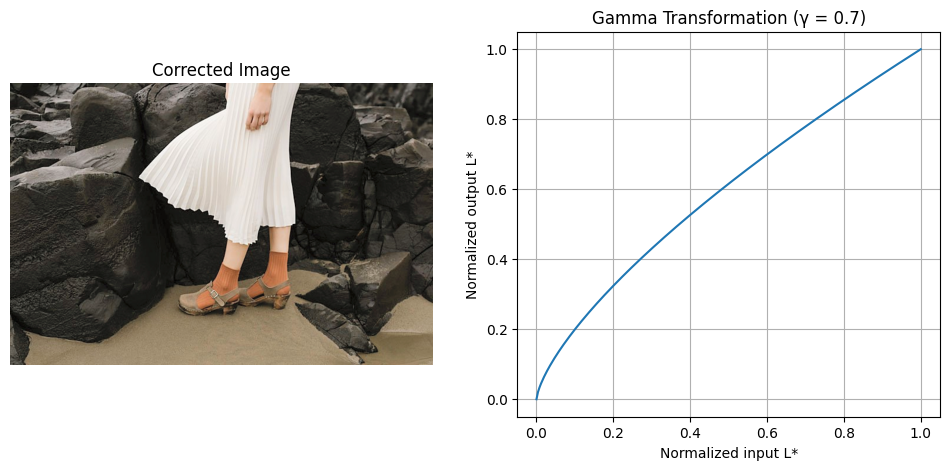

In [96]:
gamma = 0.7

L_norm = L.astype(np.float32) / 255.0
L_gamma = np.power(L_norm, gamma)
L_gamma = np.clip(L_gamma * 255,0,255).astype(np.uint8)

lab_gamma = cv2.merge([L_gamma, a, b])
corrected_image = cv2.cvtColor(lab_gamma,cv2.COLOR_LAB2RGB)

r = np.linspace(0, 1, 256)
s = r ** gamma

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(corrected_image)
plt.title("Corrected Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.plot(r, s)

plt.xlabel("Normalized input L*")
plt.ylabel("Normalized output L*")
plt.title(f"Gamma Transformation (γ = {gamma})")

plt.grid(True)
plt.show()



Since gamma < 1 the curve should be above the diagonal, showing that the output lightness is increased.

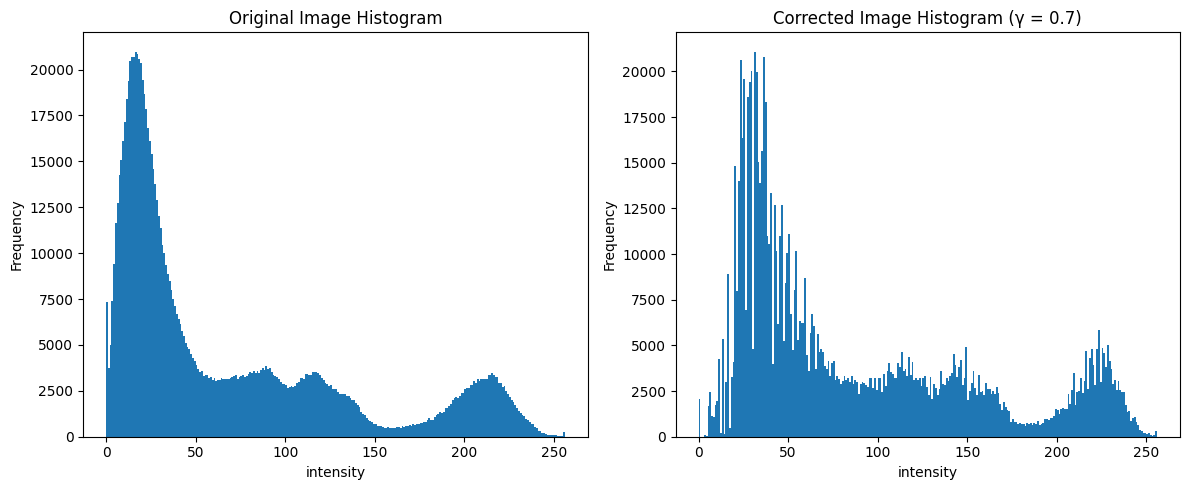

In [97]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.hist(img_rgb.ravel(),bins=256,range=(0, 256))

plt.xlabel("intensity")
plt.ylabel("Frequency")
plt.title("Original Image Histogram")


plt.subplot(1, 2, 2)

plt.hist(corrected_image.ravel(),bins=256,range=(0, 256))

plt.xlabel("intensity")
plt.ylabel("Frequency")
plt.title(f"Corrected Image Histogram (γ = {gamma})")

plt.tight_layout()
plt.show()

### (4). Vibrance Enhancement

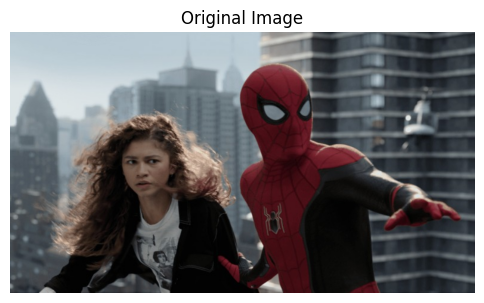

In [98]:
img = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q4.jpeg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,5))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

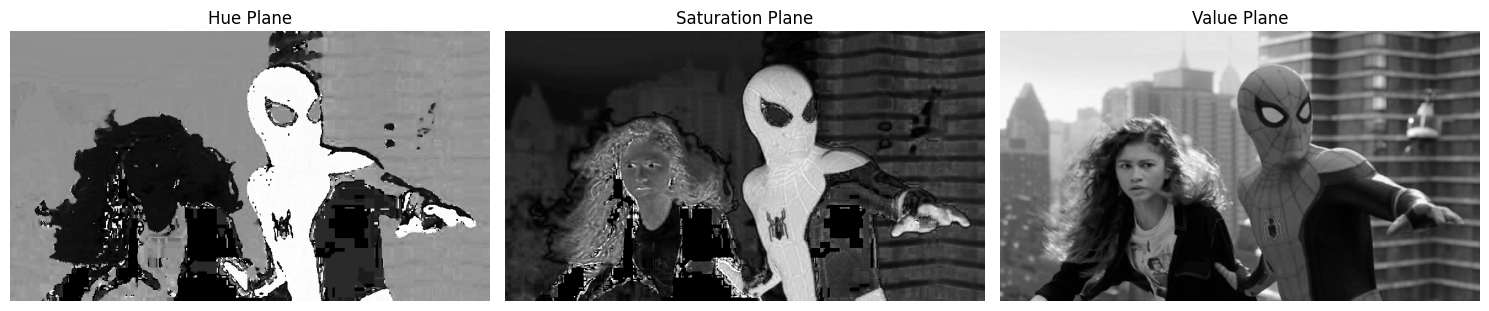

In [99]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue Plane")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation Plane")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value Plane")
plt.axis("off")

plt.tight_layout()
plt.show()

(b) Apply the aforementioned intensity transformation to the saturation plane.
(c) Adjust a to get a visually pleasing output. Report the value of a.
(d) Recombine the three planes.

In [100]:
a_values = [0,0.2, 0.4, 0.6, 0.8, 1.0]

plt.figure(figsize=(15, 8))

for i, a in enumerate(a_values):

    lookup_table = np.clip(
        x + a * 128 * np.exp(
            -((x - 128) ** 2) / (2 * sigma ** 2)
        ),
        0,
        255
    ).astype(np.uint8)

    S_enhanced = lookup_table[S]

    hsv_enhanced = cv2.merge([
        H,
        S_enhanced,
        V
    ])

    enhanced_bgr = cv2.cvtColor(
        hsv_enhanced,
        cv2.COLOR_HSV2BGR
    )

    enhanced_rgb = cv2.cvtColor(
        enhanced_bgr,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(enhanced_rgb)
    plt.title(f"a = {a}")
    plt.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'sigma' is not defined

<Figure size 1500x800 with 0 Axes>

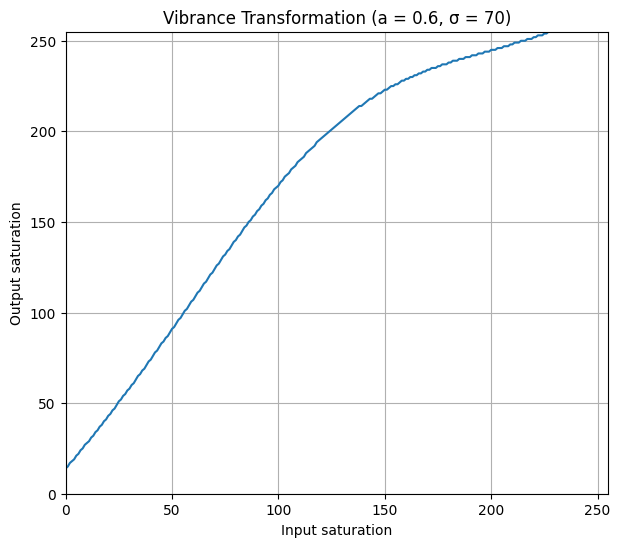

In [ ]:
a = 0.6
transformation = np.clip(
    x + a * 128 * np.exp(
        -((x - 128) ** 2) / (2 * sigma ** 2)
    ),
    0,
    255
).astype(np.uint8)

plt.figure(figsize=(7, 6))

plt.plot(x, transformation)
plt.xlabel("Input saturation")
plt.ylabel("Output saturation")
plt.title(f"Vibrance Transformation (a = {a}, σ = {sigma})")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid(True)


(np.float64(-0.5), np.float64(779.5), np.float64(437.5), np.float64(-0.5))

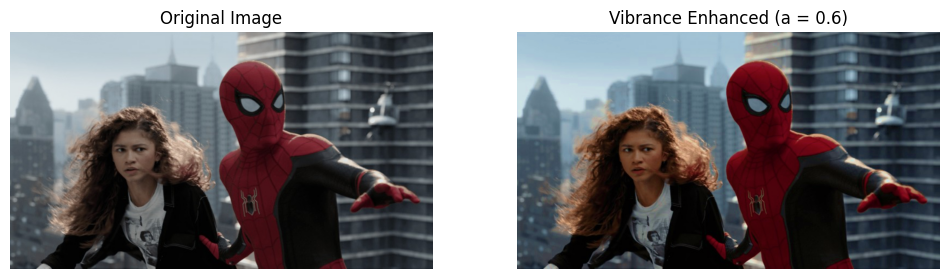

In [ ]:
S_enhanced = transformation[S]
hsv_enhanced = cv2.merge([H,S_enhanced,V])
enhanced_bgr = cv2.cvtColor(hsv_enhanced,cv2.COLOR_HSV2BGR)
enhanced_rgb = cv2.cvtColor(enhanced_bgr,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced_rgb)
plt.title(f"Vibrance Enhanced (a = {a})")
plt.axis("off")

### (5). Histogram Equalization

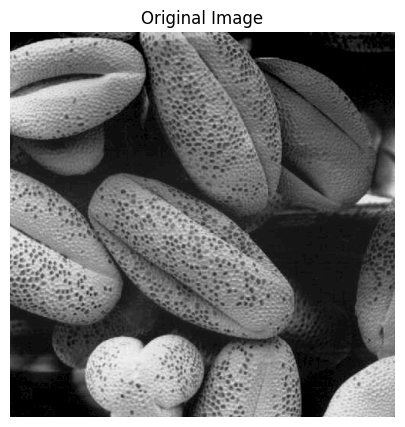

In [ ]:
img = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\shells.TIF", cv2.IMREAD_GRAYSCALE)


plt.figure(figsize=(6, 5))
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()


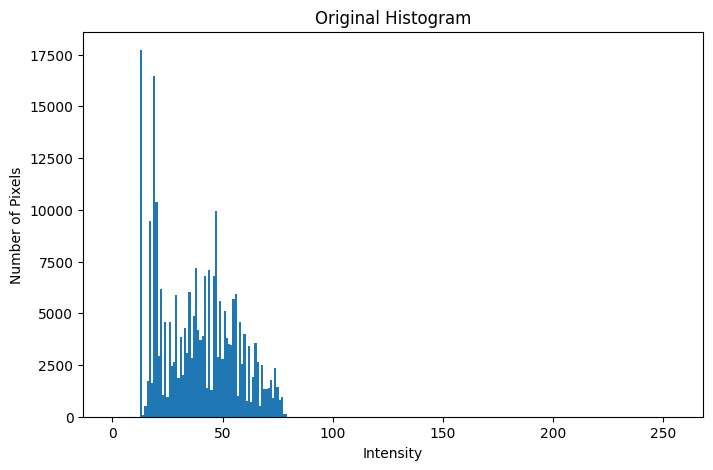

In [ ]:
hist = np.bincount(img.ravel(), minlength=256)
plt.figure(figsize=(8, 5))
plt.bar(np.arange(256), hist, width=1.0)
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Original Histogram")
plt.show()

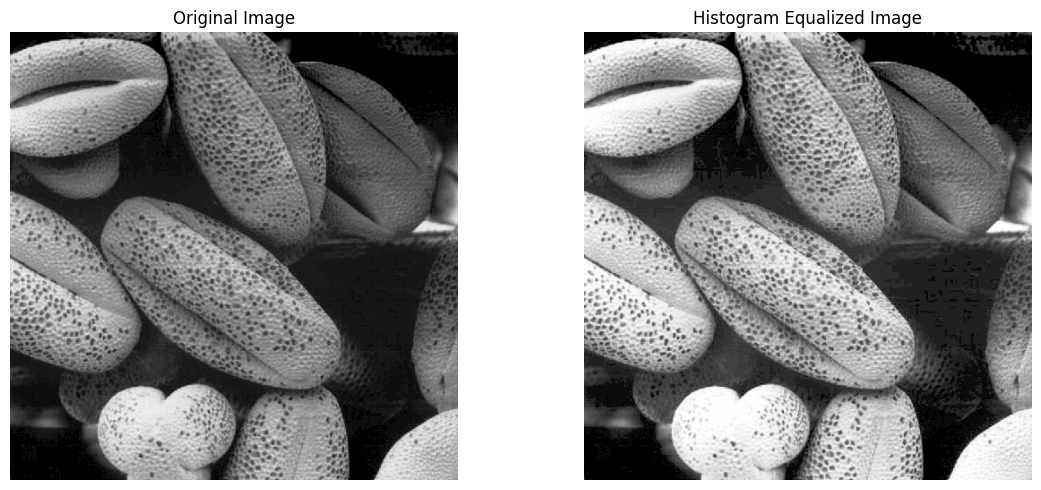

In [ ]:
cdf = np.cumsum(hist)
cdf_min = cdf[cdf > 0][0]
num_pixels = img.size

cdf_normalized = ((cdf - cdf_min) / (num_pixels - cdf_min)) * 255
cdf_normalized = np.clip(cdf_normalized, 0, 255).astype(np.uint8)
equalized_img = cdf_normalized[img]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized_img, cmap="gray")
plt.title("Histogram Equalized Image")
plt.axis("off")

plt.tight_layout()
plt.show()

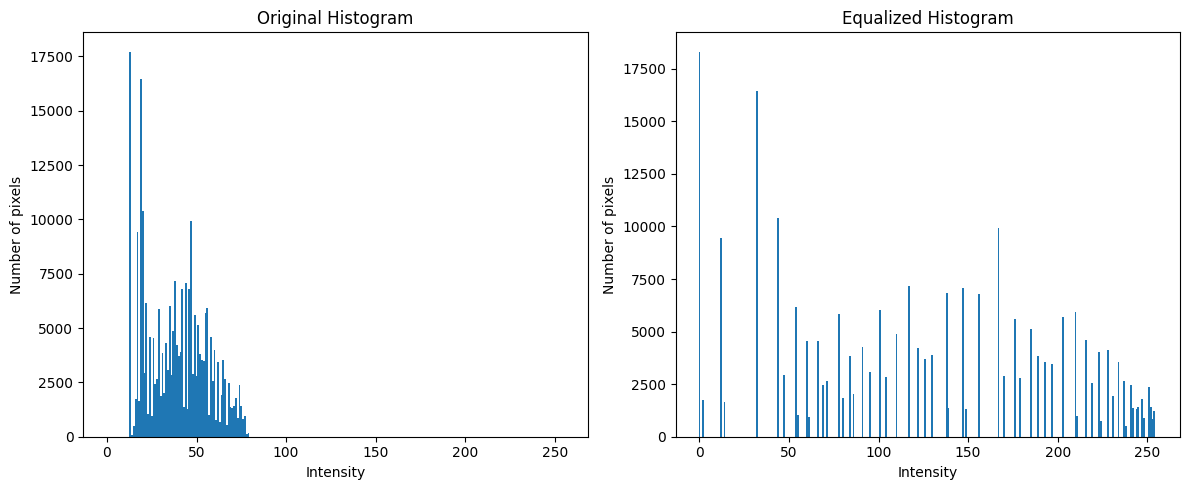

In [ ]:
equalized_hist = np.bincount(equalized_img.ravel(),minlength=256)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.bar(np.arange(256),hist,width=1.0)

plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Original Histogram")


plt.subplot(1, 2, 2)

plt.bar(np.arange(256),equalized_hist,width=1)

plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Equalized Histogram")

plt.tight_layout()
plt.show()

### (6).Histogram Equalization of the Foreground

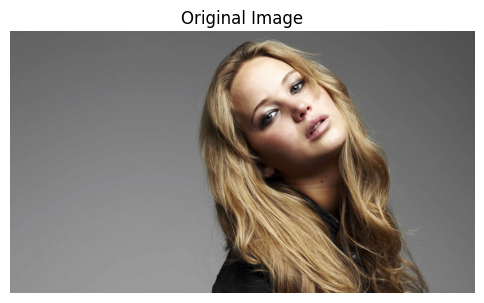

In [ ]:
img = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q6.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 5))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

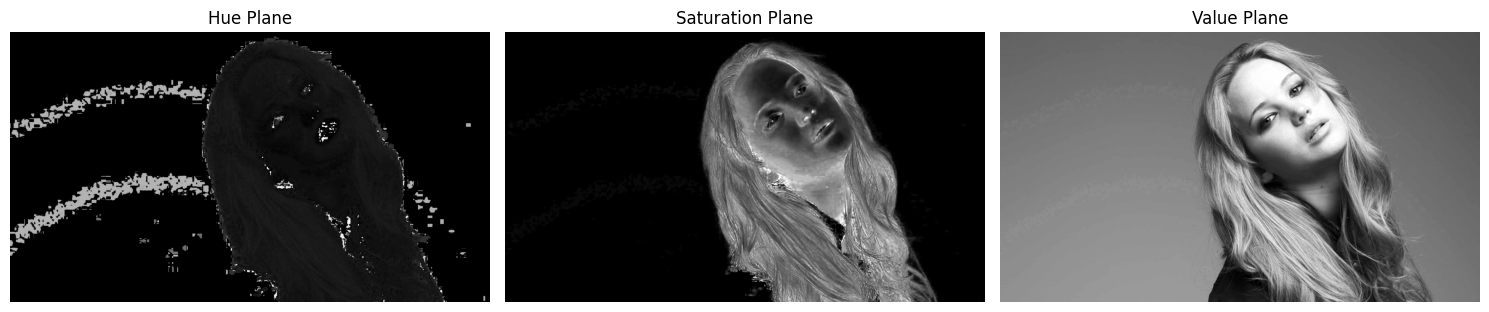

In [ ]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue Plane")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation Plane")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value Plane")
plt.axis("off")

plt.tight_layout()
plt.show()

Acoording to the H,S and V planes the Value plane gives the clearest separation between the foreground and background so that Value(V) plane is the best plane for the threshold.

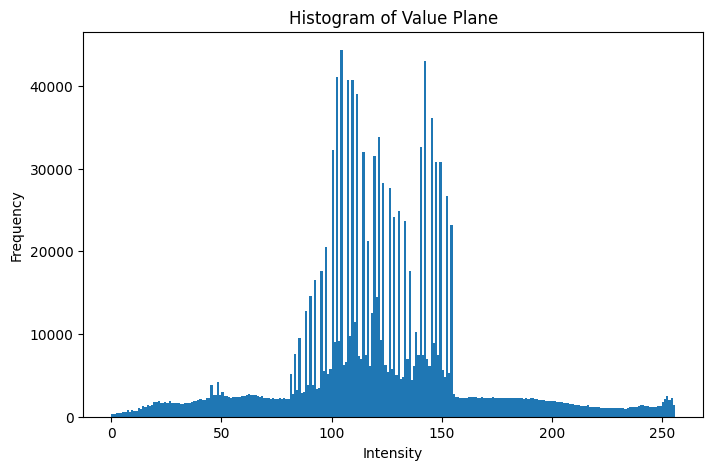

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(V.ravel(),bins=256,range=(0, 256))

plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.title("Histogram of Value Plane")

plt.show()

according to the histogram the threshold is 100

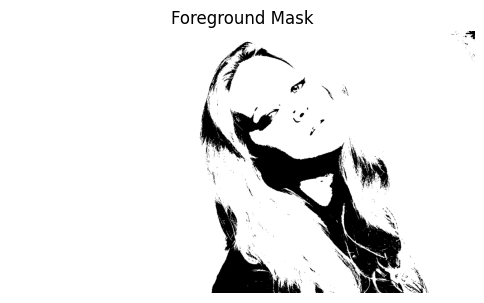

In [ ]:
threshold = 80
_, mask = cv2.threshold(V, threshold, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(6, 5))

plt.imshow(mask, cmap="gray")
plt.title("Foreground Mask")
plt.axis("off")

plt.show()




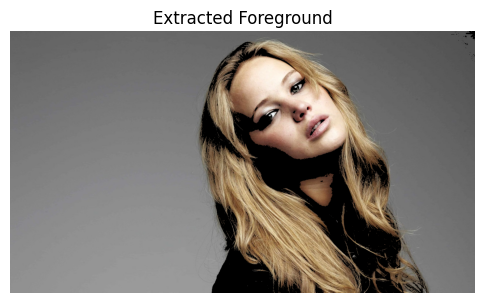

In [ ]:
foreground = cv2.bitwise_and(img,img,mask=mask)

foreground_rgb = cv2.cvtColor(foreground,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 5))

plt.imshow(foreground_rgb)
plt.title("Extracted Foreground")
plt.axis("off")

plt.show()

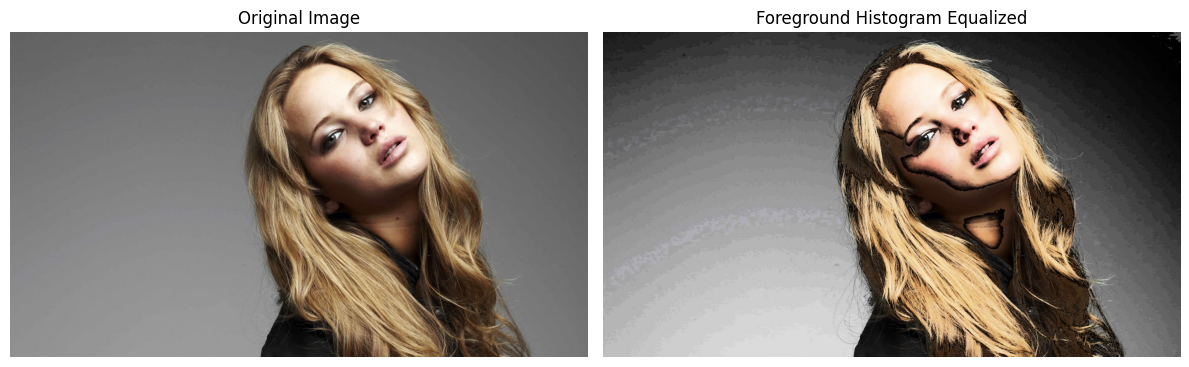

In [ ]:
foreground_V = V[mask > 0]
hist_fg = np.bincount(foreground_V,minlength=256)
cdf_fg = np.cumsum(hist_fg)
cdf_min_fg = cdf_fg[cdf_fg > 0][0]
num_fg_pixels = foreground_V.size

mapping_fg = ((cdf_fg - cdf_min_fg) /(num_fg_pixels - cdf_min_fg)) * 255

mapping_fg = np.clip(mapping_fg,0,255).astype(np.uint8)

V_equalized = V.copy()

V_equalized[mask > 0] = (mapping_fg[V[mask > 0]])

## merge the H, S, and equalized V channels to get the final HSV image
hsv_result = cv2.merge([
    H,
    S,
    V_equalized
])

## convert the HSV image back to BGR color space
result = cv2.cvtColor(
    hsv_result,
    cv2.COLOR_HSV2BGR
)
## convert the BGR image to RGB for displaying with matplotlib
result_rgb = cv2.cvtColor(
    result,
    cv2.COLOR_BGR2RGB
)

background_mask = cv2.bitwise_not(mask)
background = cv2.bitwise_and(
    img,
    img,
    mask=background_mask
)

final_result = np.where(
    mask[:, :, None] > 0,
    result,
    background
).astype(np.uint8)

final_rgb = cv2.cvtColor(
    final_result,
    cv2.COLOR_BGR2RGB
)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(final_rgb)
plt.title("Foreground Histogram Equalized")
plt.axis("off")

plt.tight_layout()
plt.show()




### (7). Sobel filtering

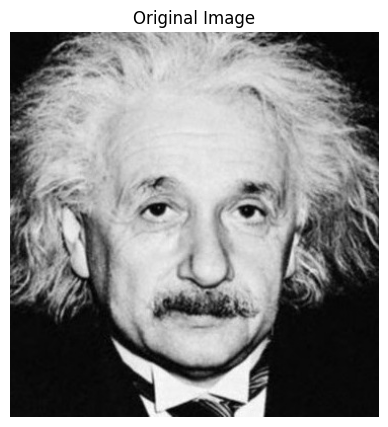

In [103]:
img = cv2.imread(r"C:\my files\5th sem\CV\assignments\images\images\q7.jpeg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(7,5))
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off");

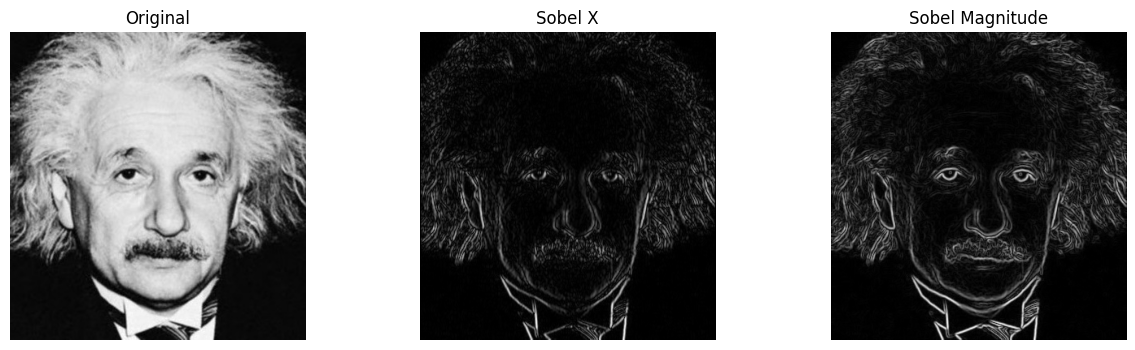

In [104]:
## define Sobel kernels for x and y directions
Gx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

Gy = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)


Ix = cv2.filter2D(img, cv2.CV_32F, Gx)
Iy = cv2.filter2D(img, cv2.CV_32F, Gy)
 
magnitude = np.sqrt(Ix**2 + Iy**2)
magnitude_display = cv2.normalize(
    magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(np.abs(Ix), cmap='gray')
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(magnitude_display, cmap='gray')
plt.title("Sobel Magnitude")
plt.axis("off")

plt.show()

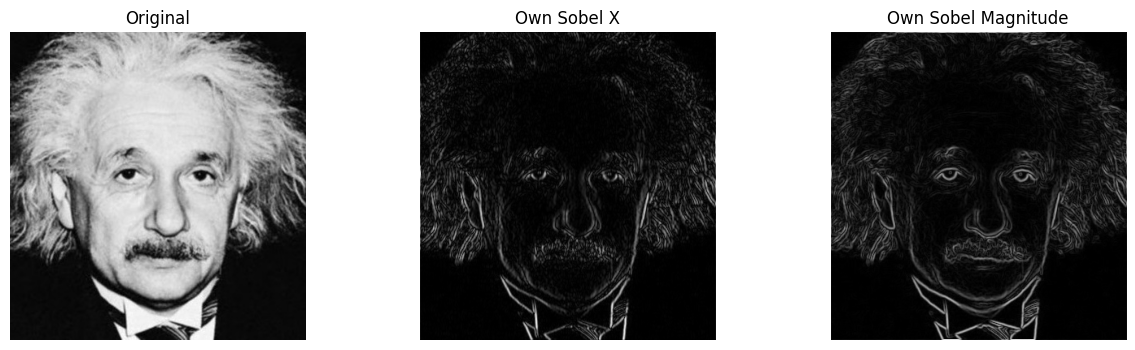

In [105]:
## define my own sobel filter
def convolution(im, kernel):
    kh, kw = kernel.shape

    pad_h = kh // 2
    pad_w = kw // 2

    padded = np.pad(
        im,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode='constant'
    )

    output = np.zeros_like(im, dtype=np.float32)

    for i in range(im.shape[0]):
        for j in range(im.shape[1]):

            region = padded[
                i:i+kh,
                j:j+kw
            ]

            output[i, j] = np.sum(region * kernel)

    return output

Ix_own = convolution(img.astype(np.float32), Gx)
Iy_own = convolution(img.astype(np.float32), Gy)

magnitude_own = np.sqrt(Ix_own**2 + Iy_own**2)

magnitude_own_display = cv2.normalize(
    magnitude_own,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(np.abs(Ix_own), cmap='gray')
plt.title("Own Sobel X")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(magnitude_own_display, cmap='gray')
plt.title("Own Sobel Magnitude")
plt.axis("off")

plt.show()

In [106]:
## Compare OpenCV vs your implementation
difference = np.abs(magnitude - magnitude_own)

print("Maximum difference:", np.max(difference))
print("Mean difference:", np.mean(difference))

Maximum difference: 987.0005
Mean difference: 1.7478977


In [107]:
smooth = np.array([
    [1],
    [2],
    [1]
], dtype=np.float32)

derivative = np.array([
    [-1, 0, 1]
], dtype=np.float32)

Gx_separable = smooth @ derivative

print(Gx_separable)

derivative_vertical = np.array([
    [-1],
    [0],
    [1]
], dtype=np.float32)

smooth_horizontal = np.array([
    [1, 2, 1]
], dtype=np.float32)

Gy_separable = derivative_vertical @ smooth_horizontal

print(Gy_separable)


[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]
[[-1. -2. -1.]
 [ 0.  0.  0.]
 [ 1.  2.  1.]]


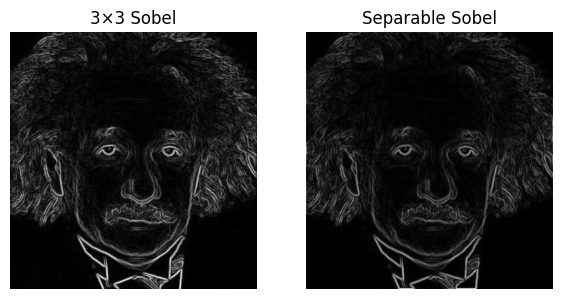

In [111]:
Ix_step1 = convolution(img.astype(np.float32), smooth)
Ix_sep = convolution(Ix_step1, derivative)

Iy_step1 = convolution(img.astype(np.float32), smooth_horizontal.T)
Iy_sep = convolution(Iy_step1, derivative_vertical)

magnitude_sep = np.sqrt(Ix_sep**2 + Iy_sep**2)

magnitude_sep_display = cv2.normalize(
    magnitude_sep,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

plt.figure(figsize=(7,6))

plt.subplot(1,2,1)
plt.imshow(magnitude_display, cmap='gray')
plt.title("3×3 Sobel")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(magnitude_sep_display, cmap='gray')
plt.title("Separable Sobel")
plt.axis("off")



plt.show()

meaning of the seperable:A filter is separable if a 2D convolution can be performed as two consecutive 1D convolutions. The Sobel filters are separable because their 3×3 kernels can be expressed as the outer product of two 1D kernels. Therefore, instead of performing a 3×3 convolution directly, the filtering can be performed using two 1D convolutions, reducing the computational complexity.


### (8). nearest neighbor and bilinear interpolation